# Analyses

Isaac T. Petersen, Zachary Demko, and Megan Schumer  
June 27, 2026

In [ ]:
#install.packages("remotes")
#remotes::install_github("DevPsyLab/petersenlab")

# Intro

# Preamble

## Install Libraries

## Load Libraries

In [ ]:
#| message: false
#| warning: false

library("petersenlab") #located here: https://github.com/DevPsyLab/petersenlab
library("knitr")
library("magick")

Linking to ImageMagick 6.9.12.98
Enabled features: fontconfig, freetype, fftw, heic, lcms, pango, raw, webp, x11
Disabled features: cairo, ghostscript, rsvg

Using 4 threads

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.1     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.3     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.2     

── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

## Load Data

In [ ]:
longitudinalStudies <- read_csv("../Data/longitudinalStudies.csv") #read_csv("./Data/longitudinalStudies.csv")

Rows: 46 Columns: 17
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (6): study, studyLabel, designType, sampleType, country, continent
dbl (8): sampleSize, yearStart, yearMostRecentAssessment, yearEnd, ageStartM...
lgl (3): prenatalRecruitment, active, interventionPrevention

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.

Rows: 20 Columns: 20
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (12): sample, sampleLabel, study, year, studyLabel, measurementOccasions...
dbl  (6): sampleSize, ageStartMin, ageStartMax, ageEndMin, ageEndMax, maxTim...
lgl  (2): registry, developmentalScaling

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.

Rows: 32 Columns: 4
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (4): facet, facetLabel, facetDefinition, positiveOpposite

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.

# Plots

## Cognitive Trajectories

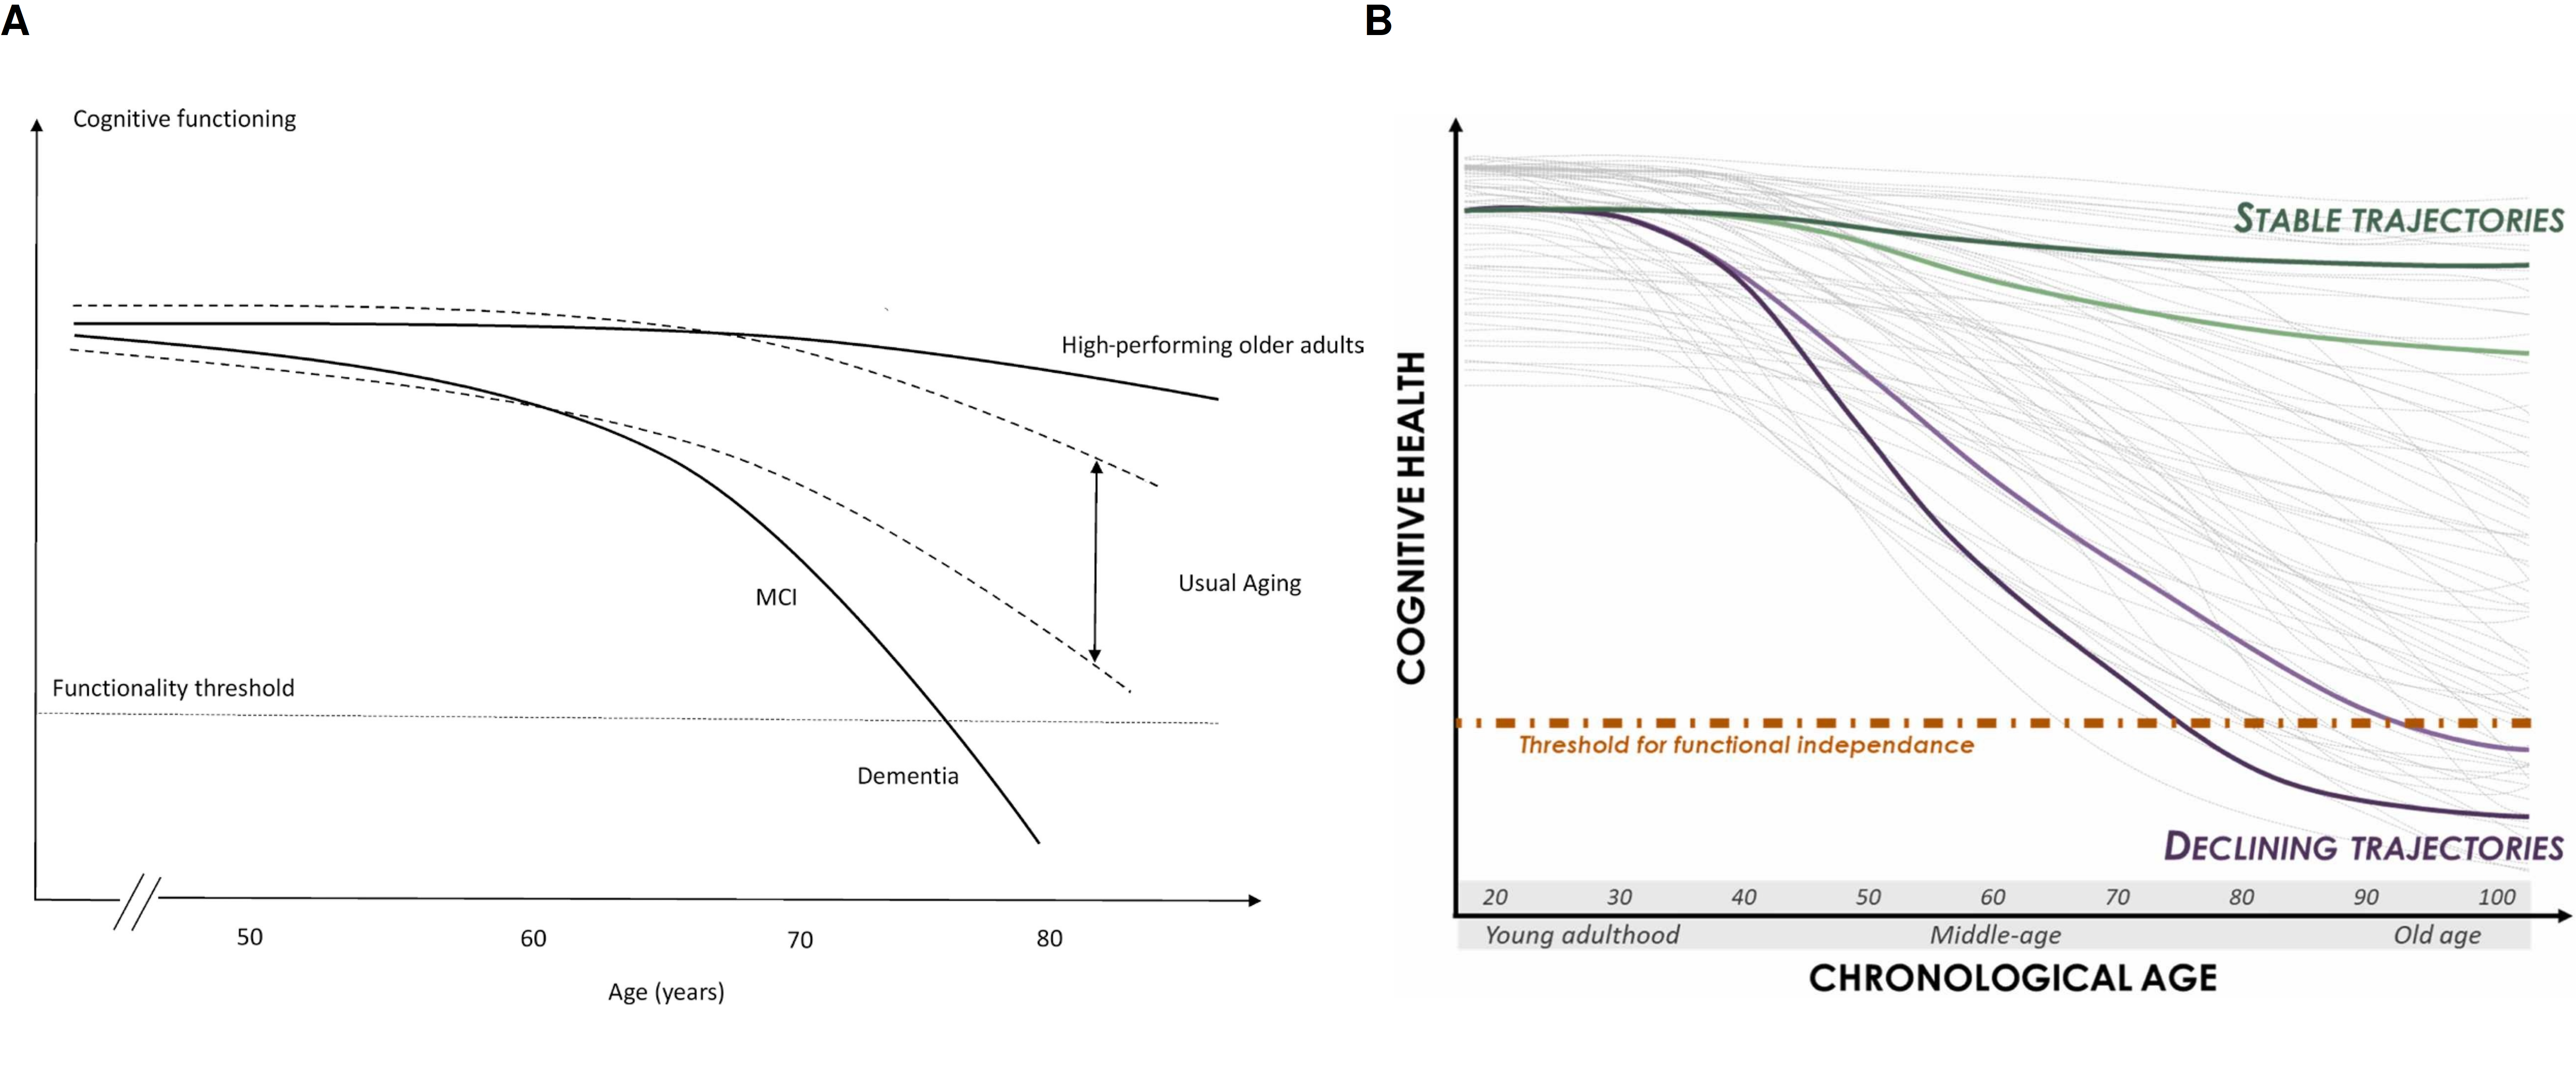

In [ ]:
#| label: fig-lifespancognitivetrajectories
#| fig-cap: "Different Cognitive Trajectories of Aging"
#| fig-alt: "Different Cognitive Trajectories of Aging"
#| apa-note: "**Panel A**: Hypothetical models for different cognitive trajectories of aging. MCI = mild cognitive impairment. (Figure in Panel A reprinted from @Borelli2018, Figure 1, p. 222. Borelli, W. V., Carmona, K. C., Studart-Neto, A., Nitrini, R., Caramelli, P., & Costa, J. C. d. (2018). Operationalized definition of older adults with high cognitive performance. *Dementia & Neuropsychologia*, *12*(3), 221–227. <https://doi.org/10.1590/1980-57642018dn12-030001>). **Panel B**: Theoretical illustration of inter-individual variability in cognitive aging trajectories. Each grey line represents one individual hypothetical cognitive health trajectory. The orange line marks the threshold for functional independence; once an individual's cognitive health drops below this level, autonomous daily living is compromised. (Figure in Panel B reprinted from @Abrous2026, Figure 1, p. 2. Abrous, D. N., Blin, N., Boraxbekk, C.-J., Catheline, G., Fitzsimons, C. P., Hilscher, M., Lemoine, M., Lopes, L. V., Maass, A., Nilsson, M., Nyberg, L., Rasmussen, L. J., Remondes, M., Sauvage, M., Schreiber, S., & Wolbers, T. (2026). Hallmarks of healthy cognitive aging: Inter-individual differences in aging trajectories. *Ageing Research Reviews*, *119*, 103102. <https://doi.org/10.1016/j.arr.2026.103102>)."
#| fig-width: 12
#| fig-height: 5
#| fig-dpi: 300

# Read images
lifespanCognitiveTrajectoriesFigA <- magick::image_read("../Figures/Borelli2018_figure1.jpg") #magick::image_read("./Figures/Borelli2018_figure1.jpg")
lifespanCognitiveTrajectoriesFigB <- magick::image_read("../Figures/Abrous2026_figure1.jpg") #magick::image_read("./Figures/Abrous2026_figure1.jpg")

# Convert images to patchwork-compatible objects
lifespanCognitiveTrajectoriesPanelA <- patchwork::wrap_elements(
  panel = grid::rasterGrob(as.raster(lifespanCognitiveTrajectoriesFigA), interpolate = TRUE)
) +
  labs(tag = "A")

lifespanCognitiveTrajectoriesPanelB <- patchwork::wrap_elements(
  panel = grid::rasterGrob(as.raster(lifespanCognitiveTrajectoriesFigB), interpolate = TRUE)
) +
  labs(tag = "B")

# Combine panels
lifespanCognitiveTrajectoriesPanelA + lifespanCognitiveTrajectoriesPanelB +
  patchwork::plot_layout(widths = c(53, 47)) &
  theme(
    plot.tag = element_text(face = "bold", size = 14),
    plot.margin = margin(0, 0, 0, 0)
  )

## Longitudinal Studies

In [ ]:
# prepare data for plot
longitudinalStudies_plotData <- bind_rows(

  # ---- start cross-section ----
  longitudinalStudies %>%
    mutate(
      segment_group = "cross-section",
      segment_type = "start_crossSection",
      ageStart = ageStartMin,
      ageEnd = ageStartMax
    ) %>%
    select(study, studyLabel, ageStart, ageEnd, segment_group, segment_type),

  # ---- core (ONLY if true longitudinal cohort span exists) ----
  longitudinalStudies %>%
    mutate(has_cor = ageStartMax < ageEndMin) %>%
    filter(has_cor) %>%
    mutate(
      segment_group = "core",
      segment_type = "core",
      ageStart = ageStartMax,
      ageEnd = ageEndMin
    ) %>%
    select(study, studyLabel, ageStart, ageEnd, segment_group, segment_type),

  # ---- end cross-section ----
  longitudinalStudies %>%
    mutate(
      segment_group = "cross-section",
      segment_type = "end_crossSection",
      ageStart = ageEndMin,
      ageEnd = ageEndMax
    ) %>%
    select(study, studyLabel, ageStart, ageEnd, segment_group, segment_type)
)

# Merge active status
longitudinalStudies_plotData <- longitudinalStudies_plotData %>%
  left_join(
    longitudinalStudies %>% select(study, active),
    by = c("study")
  )

# Order studies for plot
study_order <- longitudinalStudies %>%
  arrange(ageEndMax, ageStartMin) %>%
  pull(studyLabel)

longitudinalStudies_plotData <- longitudinalStudies_plotData %>%
  mutate(studyLabelFactor = factor(studyLabel, levels = study_order))

# Prenatal enrollment
prenatal_df <- longitudinalStudies %>%
  filter(prenatalRecruitment == TRUE) %>%
  mutate(
    age = 0,
    studyLabelFactor = factor(studyLabel, levels = study_order)
  )

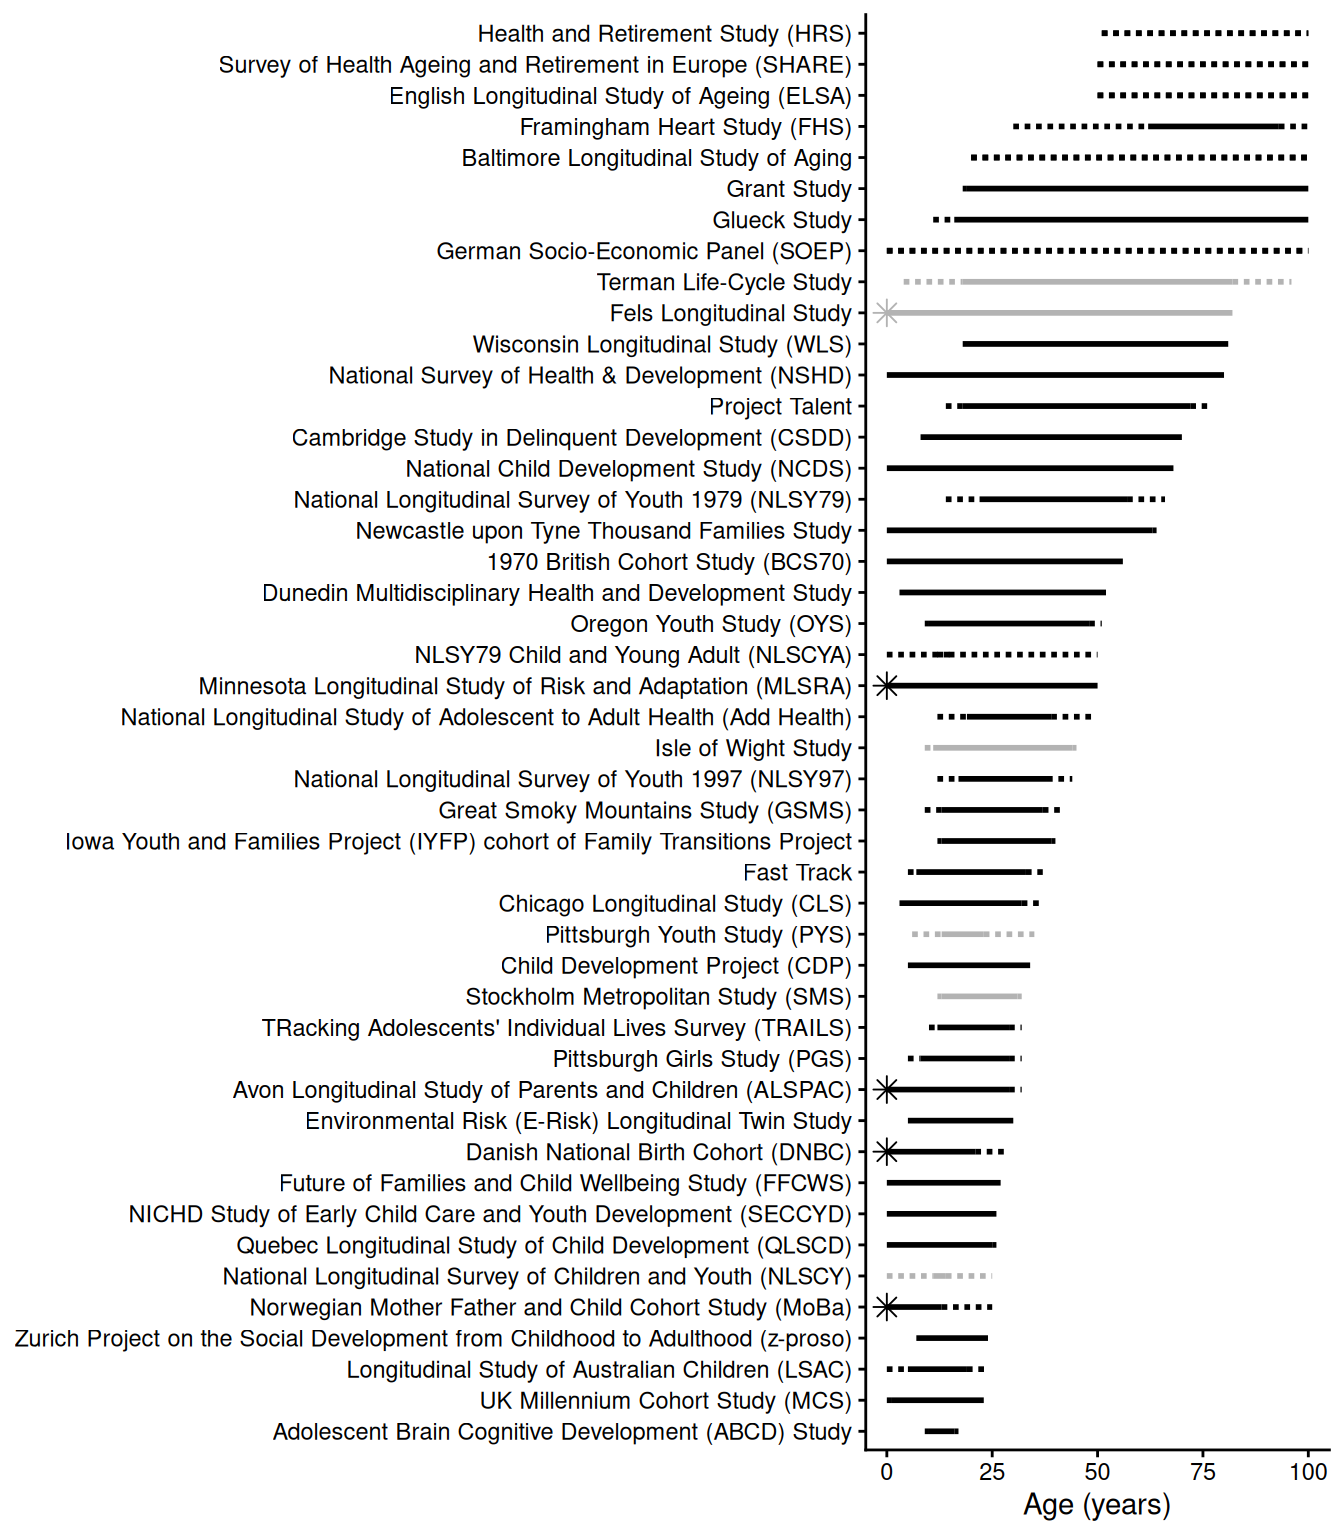

In [ ]:
#| label: fig-longitudinalstudies
#| fig-cap: "(Approximate) Ages Spanned by Various Lengthy Longitudinal Studies"
#| fig-alt: "(Approximate) Ages Spanned by Various Lengthy Longitudinal Studies"
#| apa-note: "The list of longitudinal studies is as of this writing and is not exhaustive. Studies that are no longer active are shown in gray. Studies that used developmental scaling to harmonize scores across ages (i.e., to link scores across ages onto the same scale) are in green. Solid lines reflect fully longitudinal spans (i.e., the same individuals were followed over time). Dotted lines reflect ages assessed cross-sectionally—even if some participants may have been followed longitudinally. For instance, if a study recruited 5–10-year-old children and followed each child for 20 years, the study would have dotted lines from ages 5–10 and from ages 25–30. Studies shown entirely with dotted lines assessed their full age range cross-sectionally but still included longitudinal follow-up of some participants. A star at age 0 represents that participants were enrolled before birth and the study included prenatal assessments. Ages spanned reflect ages when assessments were collected directly from participants; ages spanned do not include links to registry data (e.g., birth records, offending records). Age was truncated at 100; thus, age 100 indicates that participants were followed into their 90s (or until death)."
#| fig-height: 8

plot_longitudinalStudies <- ggplot2::ggplot(
  data = longitudinalStudies_plotData,
  mapping = aes(
    y = studyLabelFactor
  )
) +
  geom_segment(
    aes(
      x = ageStart,
      xend = ageEnd,
      yend = studyLabelFactor,
      linetype = segment_group,
      color = active
    ),
    linewidth = 1
  ) +
  scale_linetype_manual(
    values = c(
      "cross-section" = "11",
      "core" = "solid"
    ),
    guide = "none"
  ) +
  scale_color_manual(
    values = c(
      "TRUE" = "black",
      "FALSE" = "gray70"
    ),
    guide = "none"
  ) +
  geom_point(
    data = prenatal_df,
    aes(
      x = age,
      y = studyLabelFactor,
      color = active
    ),
    shape = 8,
    size = 3
  ) +
  labs(
    x = "Age (years)",
    y = NULL
  ) +
  theme_classic()

plot_longitudinalStudies

## Longitudinal Externalizing Studies

In [ ]:
# Prepare plot data
longitudinalExternalizingStudies_plotData <- bind_rows(

  # start cross-sectional span
  longitudinalExternalizingStudies %>%
    mutate(
      segment_group = "cross-section",
      ageStart = ageStartMin,
      ageEnd = ageStartMax
    ) %>%
    select(
      sample,
      sampleLabel,
      study,
      studyLabel,
      ageStart,
      ageEnd,
      segment_group
    ),

  # core longitudinal span
  longitudinalExternalizingStudies %>%
    mutate(has_core = ageStartMax < ageEndMin) %>%
    filter(has_core) %>%
    mutate(
      segment_group = "core",
      ageStart = ageStartMax,
      ageEnd = ageEndMin
    ) %>%
    select(
      sample,
      sampleLabel,
      study,
      studyLabel,
      ageStart,
      ageEnd,
      segment_group
    ),

  # end cross-sectional span
  longitudinalExternalizingStudies %>%
    mutate(
      segment_group = "cross-section",
      ageStart = ageEndMin,
      ageEnd = ageEndMax
    ) %>%
    select(
      sample,
      sampleLabel,
      study,
      studyLabel,
      ageStart,
      ageEnd,
      segment_group
    )
)

# Merge registry/developmental scaling info
longitudinalExternalizingStudies_plotData <- longitudinalExternalizingStudies_plotData %>%
  left_join(
    longitudinalExternalizingStudies %>%
      select(study, registry, developmentalScaling),
    by = "study"
  ) %>%
  mutate(
    plotColor = case_when(
      developmentalScaling ~ "developmentalScaling",
      registry ~ "registry",
      TRUE ~ "standard"
    )
  )

# Study ordering
longitudinalExternalizingStudies_order <- longitudinalExternalizingStudies %>%
  arrange(ageEndMax, ageStartMin) %>%
  pull(studyLabel)

# Add numeric study positions
study_positions <- tibble(
  studyLabel = longitudinalExternalizingStudies_order,
  study_num = seq_along(longitudinalExternalizingStudies_order)
)

# Main plotting data
longitudinalExternalizingStudies_plotData <- longitudinalExternalizingStudies_plotData %>%
  left_join(study_positions, by = "studyLabel") %>%
  mutate(
    line_y = study_num + 0.25
  )

# Measurement occasions

longitudinalExternalizingStudies_measurementOccasions <- longitudinalExternalizingStudies %>%
  filter(!is.na(measurementOccasions)) %>%
  separate_rows(
    measurementOccasions,
    sep = ";"
  ) %>%
  mutate(
    measurementOccasions = as.numeric(str_trim(measurementOccasions))
  ) %>%
  left_join(study_positions, by = "studyLabel") %>%
  mutate(
    point_y = study_num + 0.45,
    plotColor = case_when(
      developmentalScaling ~ "developmentalScaling",
      registry ~ "registry",
      TRUE ~ "standard"
    )
  )

# Sample labels
longitudinalExternalizingStudies_sampleLabels <- longitudinalExternalizingStudies %>%
  left_join(study_positions, by = "studyLabel") %>%
  mutate(
    label_x = ageStartMin,
    label_y = study_num,
    plotColor = case_when(
      developmentalScaling ~ "developmentalScaling",
      registry ~ "registry",
      TRUE ~ "standard"
    )
  )

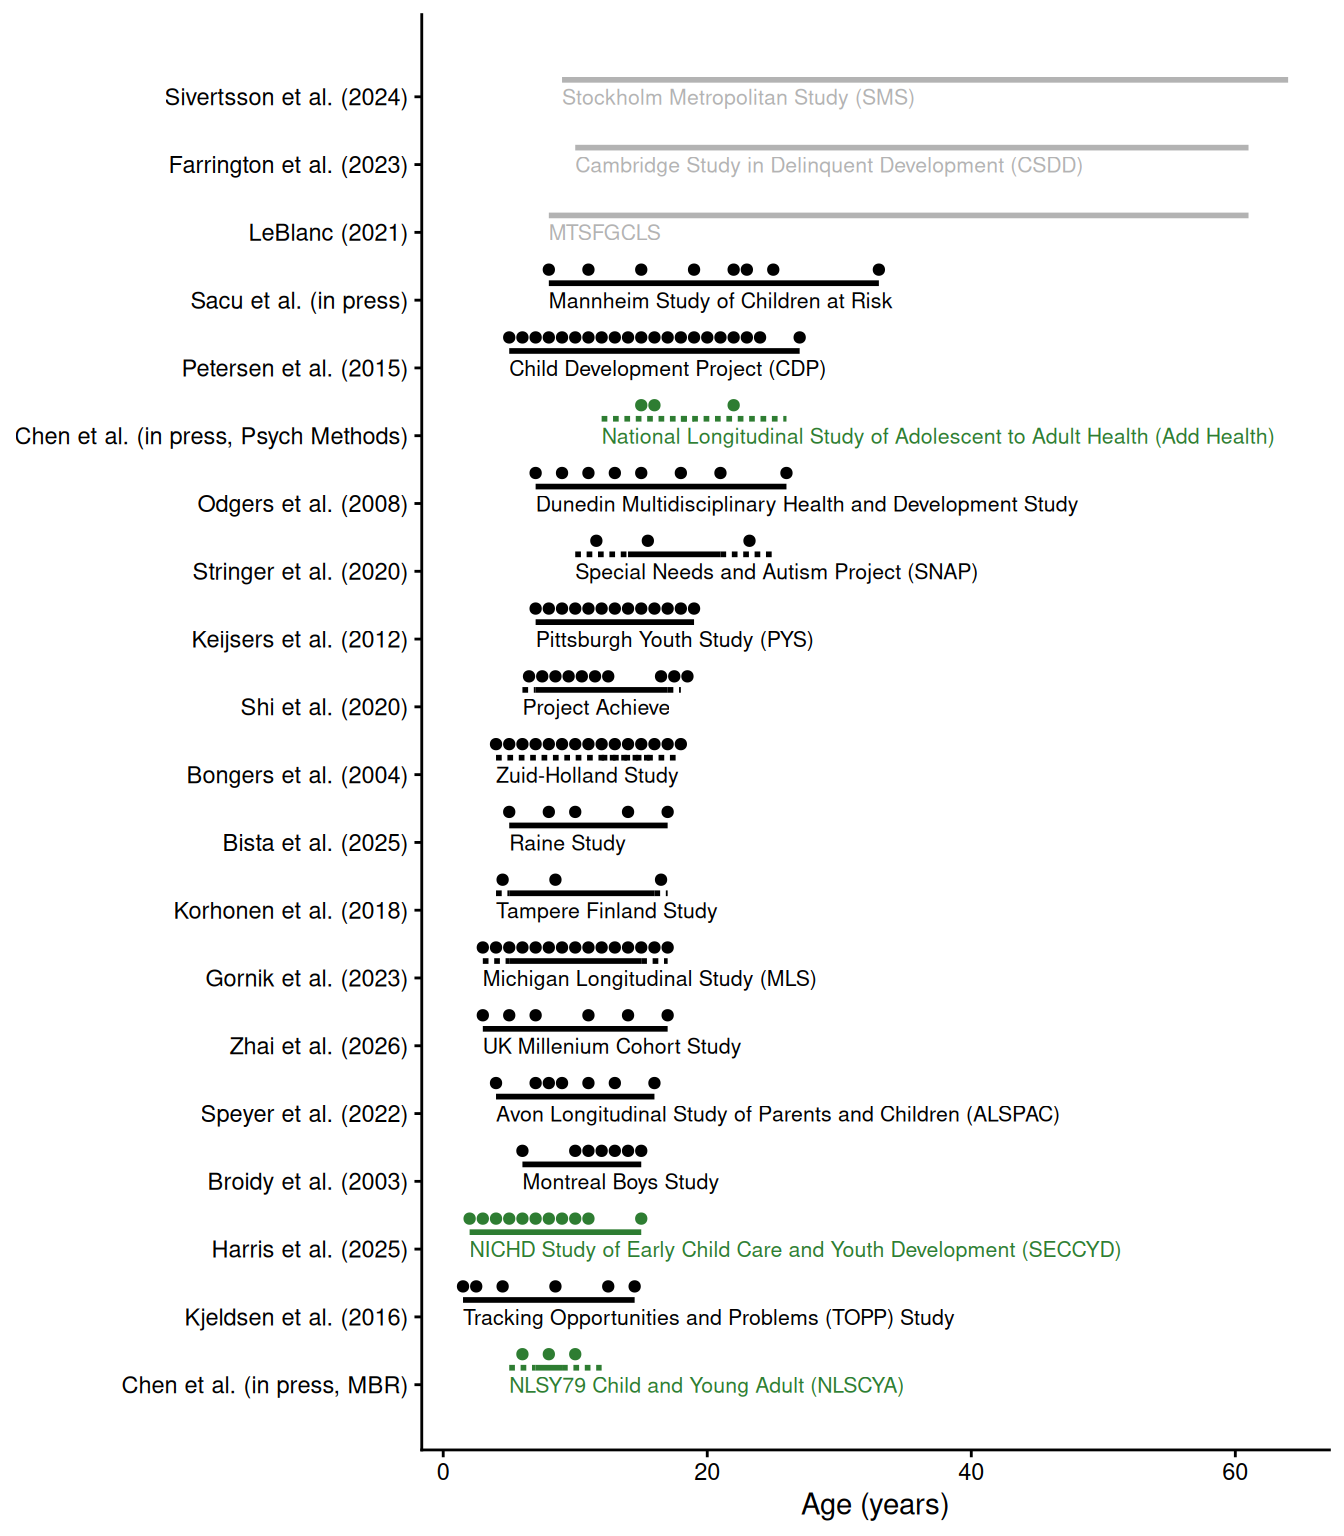

In [ ]:
#| label: fig-longitudinalexternalizingstudies
#| fig-cap: "(Approximate) Ages Spanned by Externalizing Trajectories in Various Lengthy Longitudinal Studies Examining Individuals' Trajectories of Externalizing Behavior"
#| fig-alt: "(Approximate) Ages Spanned by Externalizing Trajectories in Various Lengthy Longitudinal Studies Examining Individuals' Trajectories of Externalizing Behavior"
#| apa-note: "The list of longitudinal studies is not exhaustive. Studies that are based on registry data are shown in gray. Measurement occasions are depicted with solid circles. Note that, in some studies, measurement occasions only apply to a subset of participants in that study—in some cases, no participant was assessed at all measurement occasions. Solid lines reflect fully longitudinal spans (i.e., the same individuals were followed over time). Dotted lines reflect ages assessed cross-sectionally—even if some participants may have been followed longitudinally. For instance, if a study recruited 5–10-year-old children and followed each child for 20 years, the study would have dotted lines from ages 5–10 and from ages 25–30. Studies shown entirely with dotted lines assessed their full age range cross-sectionally but still included longitudinal follow-up of participants. 'MTSFGCLS' = Montreal Two Samples Four Generations Cross-sectional and Longitudinal Studies."
#| fig-height: 8

plot_longitudinalExternalizingStudies <- ggplot2::ggplot() +
  geom_segment(
    data = longitudinalExternalizingStudies_plotData,
    aes(
      x = ageStart,
      xend = ageEnd,
      y = line_y,
      yend = line_y,
      linetype = segment_group,
      color = plotColor
    ),
    linewidth = 1
  ) +
  geom_point(
    data = longitudinalExternalizingStudies_measurementOccasions,
    aes(
      x = measurementOccasions,
      y = point_y,
      color = plotColor
    ),
    size = 1.5
  ) +
  geom_text(
    data = longitudinalExternalizingStudies_sampleLabels,
    aes(
      x = label_x,
      y = label_y,
      label = sampleLabel,
      color = plotColor
    ),
    hjust = 0,
    vjust = 0.5,
    size = 2.8
  ) +
  scale_y_continuous(
    breaks = study_positions$study_num,
    labels = study_positions$studyLabel
  ) +
  scale_linetype_manual(
    values = c(
      "cross-section" = "11",
      "core" = "solid"
    ),
    guide = "none"
  ) +
  scale_color_manual(
    values = c(
      standard = "black",
      registry = "gray70",
      developmentalScaling = "#2E7D32"
    ),
    guide = "none"
  ) +
  coord_cartesian(
    clip = "off"
  ) +
  labs(
    x = "Age (years)",
    y = NULL
  ) +
  theme_classic()

plot_longitudinalExternalizingStudies

# Tables

## Externalizing Facets

In [ ]:
#| label: tbl-externalizingfacets
#| tbl-cap: "Externalizing Facets Identified in Content Analysis of Externalizing Measures."

knitr::kable(
  externalizingFacets %>% select(facetLabel, facetDefinition, positiveOpposite),
  col.names = c("Facet","Definition","Positive Opposite")
)

  ------------------------------------------------------------------------------------------------------------------------------------------------------
  Facet                                                                   Definition                                  Positive Opposite
  ----------------------------------------------------------------------- ------------------------------------------- ----------------------------------
  Attention seeking/Exhibitionism                                         Exaggerated or dramatic expressions,        Humility/Appropriate
                                                                          interrupting others, inappropriate or       self-expression
                                                                          provocative behaviors, provoking reactions  

  Behavioral addiction                                                    Non-substance addictions (e.g., gambling,   Self-regulated engagement/Balanced
                                                                          video games, risky sex, pornography, food,  lifestyle
                                                                          the internet, mobile devices, shopping)     

  Blame externalization                                                   Attribute cause of problems or failures to  Personal
                                                                          external factors, feeling like a victim,    responsibility/Accountability
                                                                          blaming others                              

  Boredom proneness                                                       Expressing boredom often, difficulty        Curiosity/Sustained engagement
                                                                          maintaining interest, lack of engagement    

  Callous aggression                                                      Inflicting harm without feeling remorse or  Compassionate
                                                                          concern, usually proactive/intentional      protection/Benevolence

  Callousness/Disregard for others/Low concern/Low                        Emotional detachment, indifference to       Empathy/Compassion/Concern for
  empathy/Selfishness/Egocentricity                                       well-being of others                        others/Helping others/Sharing

  Deceitfulness/Fraud/Lying/Cheating/Dishonesty/Sneakiness/Exploitation   Keeping the truth hidden, especially to get Honesty/Integrity/Fairness
                                                                          an advantage (e.g., lying, witholding       
                                                                          information, manipulation, making false     
                                                                          promises)                                   

  Deviant peers                                                           Affiliating with peer who engage in deviant Prosocial peer affiliations
                                                                          or delinquent behaviors                     

  Destructive aggression/Destruction of property                          Destruction of property, self, or others,   Constructiveness/Care for property
                                                                          objects                                     

  Distractibility/Inattention/Attention                                   Difficulty maintaining focus, attention, or Attentional control/Sustained
  dysregulation/Forgetfulness/Daydreaming                                 concentration , frequenct attention shifts  attention

  Domineering/Bossiness                                                   Asserting control, power, and authority in  Collaborativeness
                                                                          an overbearing or oppressive manner         

  Excitement seeking/Risk taking/Sensation seeking                        Tendency to pursue new and different        Prudent exploration/Measured
                                                                          sensations, especially intense,             novelty seeking
                                                                          exhilerating, thrilling, etc. (e.g., risk   
                                                                          taking, preference for novelty, intensity)  

  Grandiosity/Overconfidence                                              Exhaggerated sense of self-importance,      Realistic self-confidence
                                                                          sense of superiority or specialness         

  Hostility/Rudeness                                                      Hostile behavior, unfriendliness,           Warmth/Friendliness/Kindness
                                                                          resentment, antagonism, ranging from mild   
                                                                          irritation to intense rage, interpret       
                                                                          others' behavior as hostile                 

  Hyperactivity                                                           High levels of physical activity,           Behavioral regulation/Calm
                                                                          restlessness, difficulty engaging in quiet  engagement
                                                                          activities                                  

  Impulsivity/Disinhibition/Impatient urgency/(Low) Planful control       Tendency to act without thinking,           Planful control
                                                                          disinhibited engagement                     

  Irresponsibility                                                        Failing to meet obligations, avoiding       Responsibility/Conscientiousness
                                                                          addressing difficulties                     

  (Low) Dependability                                                     Low reliability, consistency,               Dependability/Reliability
                                                                          trustworthiness                             

  (Low) Perfectionism/(Dis)organization/(Low) Planning                    Unconcerned about achievement, low          Organization/Diligence
                                                                          motivation, lack of organization and        
                                                                          planning, doesn't have to be about school   
                                                                          or work                                     

  (Low) Performance Concern/(Low) School/Work Performance/ (Low)          Low concern about how one's abilities or    Achievement motivation
  Workaholism                                                             actions are evaluated, specific to contexts 
                                                                          in which others have expectations for       
                                                                          performance (e.g., school and work),        
                                                                          specifically low effort rather than         
                                                                          performance; low workaholism                

  Manipulativeness/Psychological aggression                               Tendency to influence or control others to  Sincerity/Authenticity
                                                                          achieve one's own goals or desires, e.g.,   
                                                                          playing the victim, flattery, gaslighting,  
                                                                          guilt-tripping, psychological aggression    

  Mistrust/Suspiciousness/Paranoia                                        Lack of confidence in the reliability,      Interpersonal trust (appropriately
                                                                          intentions of others, difficulty forming    calibrated)
                                                                          close relationships with others, difficulty 
                                                                          forgiving                                   

  Oppositionality/Stubbornness                                            Persistent and defiant attitude, tendency   Cooperativeness
                                                                          to challenge authority, refusal to comply,  
                                                                          argumentativeness (could include while      
                                                                          complying), etc.                            

  Physical aggression                                                     Use of physical force or violence to harm   Respect for others' bodies/Helping
                                                                          others or their property                    others

  Punishment insensitivity                                                Doesn't change behavior after punishment,   Responsive to consequences
                                                                          high tolerance for negative outcomes        

  Rebelliousness/Rule-breaking/Noncompliance                              Doing things differently than one is asked  Compliance/Civic responsibility
                                                                          to do (e.g., breaking house rules)          

  Relational aggression                                                   Aggression intended to harm others through  Inclusion
                                                                          deliberate manipulation of their social     
                                                                          standing and relationships (e.g.,           
                                                                          exclusion, speaking negatively of another,  
                                                                          etc)                                        

  Sexual aggression                                                       Engaging in sexual activity with someone    Respect for consent
                                                                          who does not or cannot consent to that      
                                                                          behavior, or threatening to do so (e.g.,    
                                                                          harrassment)                                

  Impulsive sexual behavior/Risky sexual behavior                         Engaging in risky sexual activity (e.g.,    Responsible sexual decision-making
                                                                          sex without contraceptives)                 

  (Harmful) Substance Use/Problems                                        Harmful use of any drugs (e.g., alcohol,    Healthy choices around substance
                                                                          tobacco, illegal drugs)                     use

  Theft/Stealing                                                          Unauthorized taking of someone else's       Respect for people's possessions
                                                                          property without their knowledge or consent 

  Verbal Aggression                                                       Communication with an intention to harm an  Respectful communication
                                                                          individual through words, tone or manner    
  ------------------------------------------------------------------------------------------------------------------------------------------------------


# Session Info

In [ ]:
sessionInfo()

R version 4.6.1 (2026-06-24)
Platform: x86_64-pc-linux-gnu
Running under: Ubuntu 24.04.4 LTS

Matrix products: default
BLAS:   /usr/lib/x86_64-linux-gnu/openblas-pthread/libblas.so.3 
LAPACK: /usr/lib/x86_64-linux-gnu/openblas-pthread/libopenblasp-r0.3.26.so;  LAPACK version 3.12.0

locale:
 [1] LC_CTYPE=C.UTF-8       LC_NUMERIC=C           LC_TIME=C.UTF-8       
 [4] LC_COLLATE=C.UTF-8     LC_MONETARY=C.UTF-8    LC_MESSAGES=C.UTF-8   
 [7] LC_PAPER=C.UTF-8       LC_NAME=C              LC_ADDRESS=C          
[10] LC_TELEPHONE=C         LC_MEASUREMENT=C.UTF-8 LC_IDENTIFICATION=C   

time zone: UTC
tzcode source: system (glibc)

attached base packages:
[1] grid      stats     graphics  grDevices utils     datasets  methods  
[8] base     

other attached packages:
 [1] lubridate_1.9.5   forcats_1.0.1     stringr_1.6.0     dplyr_1.2.1      
 [5] purrr_1.2.2       readr_2.2.0       tidyr_1.3.2       tibble_3.3.1     
 [9] ggplot2_4.0.3     tidyverse_2.0.0   patchwork_1.3.2   magick_2.9.1  

## Rstudio Version

In [ ]:
#rstudioapi::versionInfo()